# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

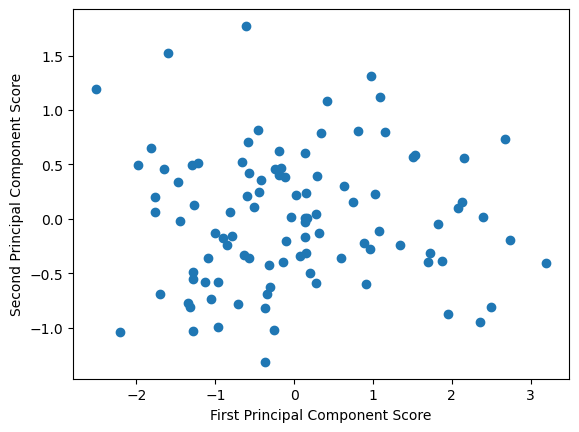

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

### Answer to Number 2 :
 The three outliers in the upper-left corner have low first principal component scores, indicating they likely have low values for series_3, since the first PC is heavily weighted on series_3. They also have high second principal component scores, which suggests relatively high values for series_1 and series_2 compared to series_3, though it’s harder to separate their individual contributions because series_1 and series_2 are highly correlated by design. This PCA scatter plot effectively highlights clusters and anomalies but has limitations, as interpreting the PCs without the loadings is difficult, and relative relationships between variables can be obscured. A pairplot of all three series would better reveal their direct relationships and confirm that series_1 and series_2 are nearly linear, while variation in series_3 explains most of the observed spread.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## Multivariate Analysis

In [4]:
#load datasets
churn_dataset = pd.read_csv("customer_churn_cleaned.csv")
marketing_dataset = pd.read_csv("marketing_campaign_cleaned.csv")
predict_conversion_dataset = pd.read_csv("predict_conversion_cleaned.csv")

#preview each dataset
print("Customer Churn Dataset:")
display(churn_dataset.head())

print("Marketing Campaign Dataset:")
display(marketing_dataset.head())

print("Predict Conversion Dataset:")
display(predict_conversion_dataset.head())

Customer Churn Dataset:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


Marketing Campaign Dataset:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


Predict Conversion Dataset:


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


### Customer Churn

c:\Users\jalva\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


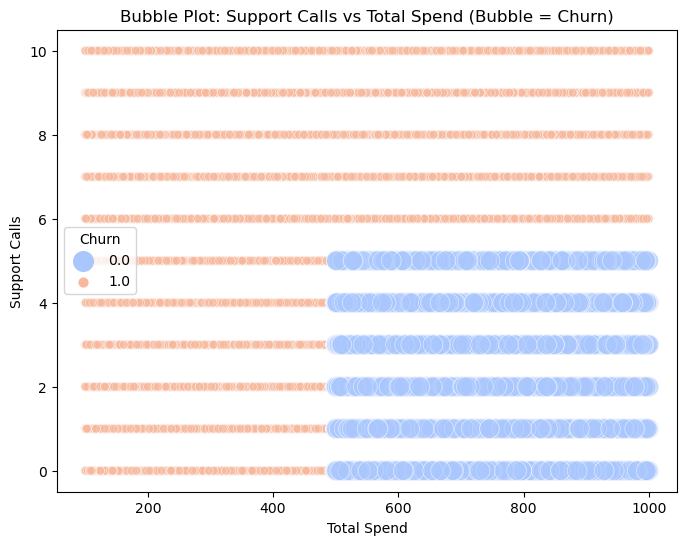

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

#bubble plot: total spend vs support calls with churn as size
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=churn_dataset,
    x="Total Spend",
    y="Support Calls",
    size="Churn",
    sizes=(40, 200),
    hue="Churn",
    palette="coolwarm",
    alpha=0.6
)
plt.title("Bubble Plot: Support Calls vs Total Spend (Bubble = Churn)")
plt.xlabel("Total Spend")
plt.ylabel("Support Calls")
plt.legend(title="Churn")
plt.show()


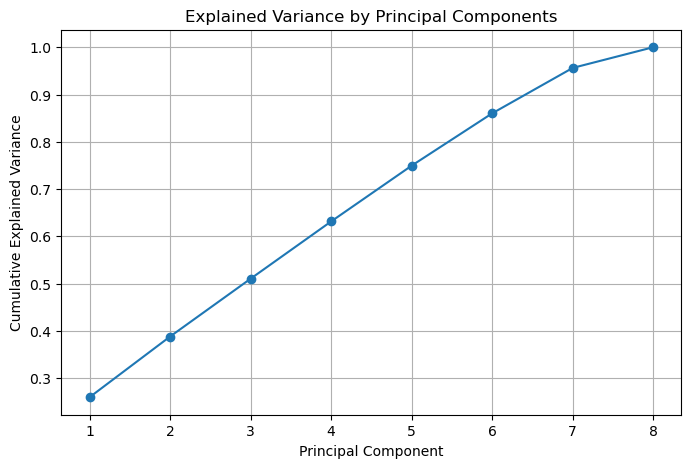

Variance captured by PC1: 25.98%


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#drop ID and non-numeric columns before PCA
churn_numeric = churn_dataset.drop(columns=["CustomerID"])

#keep only numeric columns
churn_numeric = churn_numeric.select_dtypes(include=["number"])

#scale the numeric data
churn_scaled = StandardScaler().fit_transform(churn_numeric)

#run PCA
pca = PCA()
pca.fit(churn_scaled)

#explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

#plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o')
plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

#variance captured by first component
print(f"Variance captured by PC1: {explained_variance[0]:.2%}")



In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

#features and target
features = churn_dataset[["Support Calls", "Total Spend", "Payment Delay"]]
target = churn_dataset["Churn"]

#fit model
model = LinearRegression()
model.fit(features, target)
preds = model.predict(features)

#evaluate
r2 = r2_score(target, preds)
print(f"Linear Regression R² score (Churn prediction): {r2:.3f}")


Linear Regression R² score (Churn prediction): 0.464


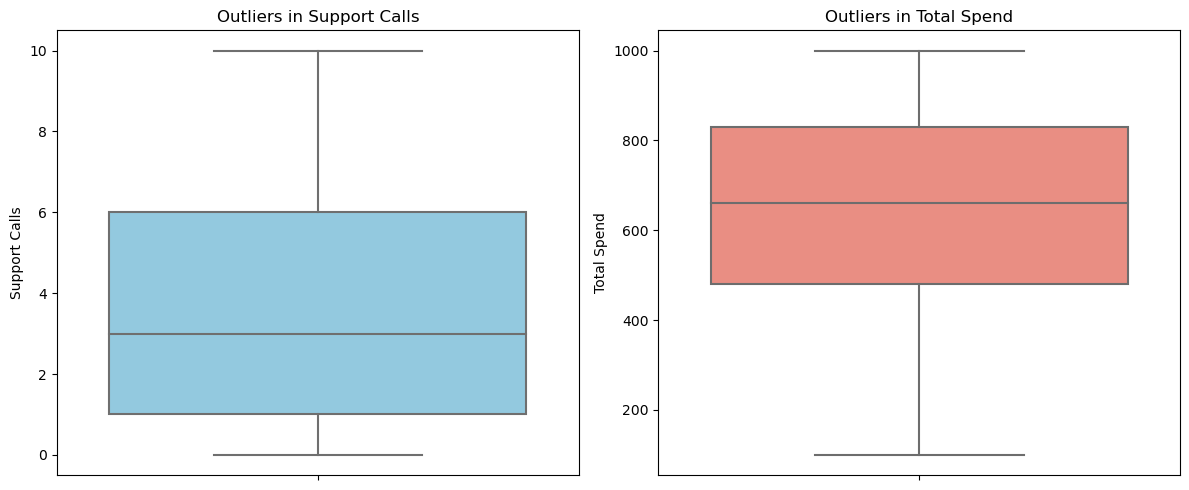

In [9]:
#boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=churn_dataset, y="Support Calls", color="skyblue")
plt.title("Outliers in Support Calls")

plt.subplot(1, 2, 2)
sns.boxplot(data=churn_dataset, y="Total Spend", color="salmon")
plt.title("Outliers in Total Spend")

plt.tight_layout()
plt.show()


### Customer Churn Dataset Analysis Summary

#### Bubble Plot
The bubble plot of Support Calls vs. Total Spend shows a clear visual separation:
- Customers with low support calls and high spend (bottom-right) are less likely to churn.
- Customers with high support calls consistently show a high churn rate (larger orange bubbles).
- This suggests churn is influenced by both dissatisfaction and lower customer value.

#### Principal Component Analysis (PCA)
- The first principal component (PC1) captures ~26% of the total variance.
- The first 4 components together capture more than 65%, and about 80% is explained with the first 6 components.
- This indicates that dimensionality reduction to 2 or 3 components would lose some meaningful structure, but reducing to 5–6 components would be viable for modeling.

#### Linear Regression (Churn ~ Support Calls + Total Spend + Payment Delay)
- The regression model produced an R² of ~0.464 .
- Support Calls was the most predictive of churn.
- This confirms the insights from the correlation heatmap and bubble plot — heavy support usage and poor payment behavior relate to churn.

#### Outlier Detection
- Support Calls has a range from 0 to 10, with some customers at the extreme upper limit — these are likely high-friction accounts.
- Total Spend shows a wider distribution with several high-spending outliers. These could represent premium or long-standing customers.


### Conclusions

- Multivariate relationships (e.g. between Support Calls, Spend, and Churn) are strong and interpretable.
- PCA suggests some redundancy among variables — 6 components retain most variance.
- Outliers are informative rather than problematic and may represent meaningful user segments (e.g. VIPs or frequent complainers).



### Marketing Data Set 

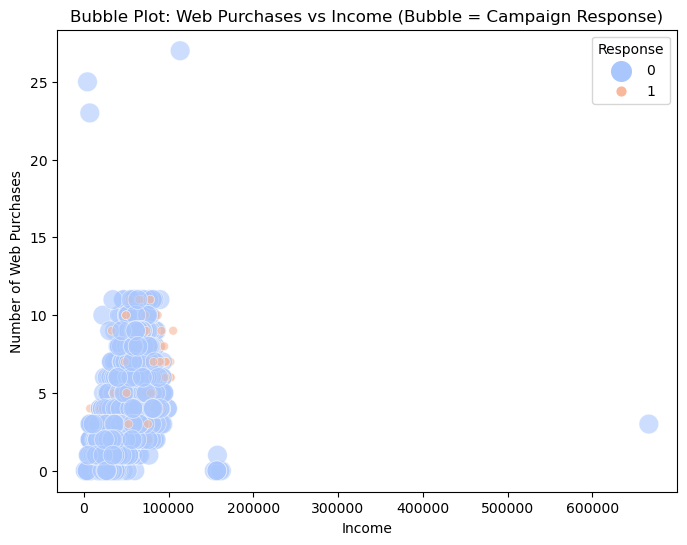

In [10]:
#bubble plot: income vs web purchases with response as size
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=marketing_dataset,
    x="Income",
    y="NumWebPurchases",
    size="Response",
    sizes=(40, 200),
    hue="Response",
    palette="coolwarm",
    alpha=0.6
)
plt.title("Bubble Plot: Web Purchases vs Income (Bubble = Campaign Response)")
plt.xlabel("Income")
plt.ylabel("Number of Web Purchases")
plt.legend(title="Response")
plt.show()


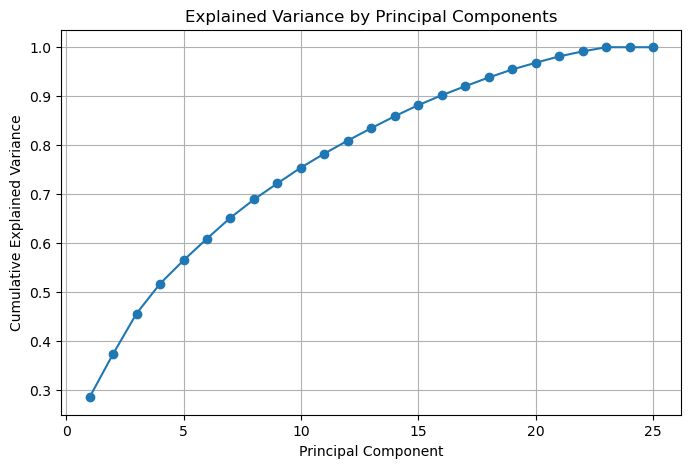

Variance captured by PC1: 28.44%


In [11]:
#drop ID and non-numeric columns
marketing_numeric = marketing_dataset.drop(columns=["ID"])
marketing_numeric = marketing_numeric.select_dtypes(include=["number"])

#scale data
marketing_scaled = StandardScaler().fit_transform(marketing_numeric)

#run PCA
pca = PCA()
pca.fit(marketing_scaled)

#explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

#plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o')
plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

#print first component variance
print(f"Variance captured by PC1: {explained_variance[0]:.2%}")


In [12]:
#features and target
features = marketing_dataset[["MntWines", "NumWebPurchases", "Income"]]
target = marketing_dataset["Response"]

#fit model
model = LinearRegression()
model.fit(features, target)
preds = model.predict(features)

#evaluate
r2 = r2_score(target, preds)
print(f"Linear Regression R² score (Response prediction): {r2:.3f}")


Linear Regression R² score (Response prediction): 0.061


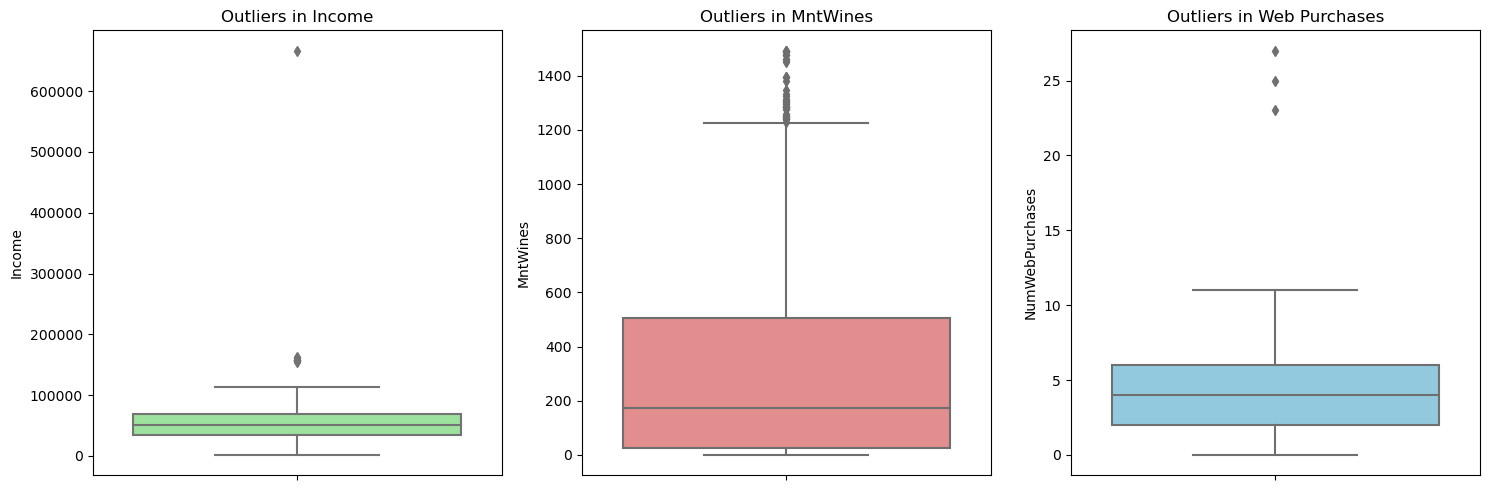

In [13]:
#boxplots for top variables
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=marketing_dataset, y="Income", color="lightgreen")
plt.title("Outliers in Income")

plt.subplot(1, 3, 2)
sns.boxplot(data=marketing_dataset, y="MntWines", color="lightcoral")
plt.title("Outliers in MntWines")

plt.subplot(1, 3, 3)
sns.boxplot(data=marketing_dataset, y="NumWebPurchases", color="skyblue")
plt.title("Outliers in Web Purchases")

plt.tight_layout()
plt.show()


### Marketing Campaign Dataset Analysis Summary

#### Bubble Plot
The bubble plot of Income vs. Number of Web Purchases, with bubble size representing Response, reveals:
- Most data points cluster below \$100,000 income and under 10 purchases.
- There are a few outliers with very high income or purchase counts.
- Very few customers responded to the campaign (small red bubbles), and responses appear scattered without a clear income or purchase threshold.

#### Principal Component Analysis (PCA)
- PC1 captures 28.44% of the total variance.
- About 70–75% of the variance is explained by the first 9–10 components.
- This suggests that while dimensionality reduction is possible, the dataset has more distributed variance than Dataset 1 (Customer Churn), requiring more components to preserve structure.

#### Linear Regression (Response ~ MntWines + NumWebPurchases + Income)
- The model yielded an R² score of 0.061, indicating very weak predictive power.
- This suggests that even though these features are somewhat correlated with Response, they are not sufficient to accurately model campaign response behavior.

#### Outlier Detection
- Income has several large outliers, including one over \$600,000, which may skew model interpretation.
- MntWines includes high-spending customers (over \$1200) that are statistical outliers.
- Web Purchases shows moderate outliers beyond 25 purchases, which may represent a small segment of hyperactive customers.

### Conclusions

- The predictive relationship between variables and response is weak in this dataset.
- PCA suggests moderate dimensionality reduction is possible, though more components are needed than in the Customer Churn Dataset.
- Outliers in Income and MntWines are significant and should be treated (transformed or capped) before modeling.
- The data is usable but may benefit from additional feature engineering (e.g., segmenting users, normalizing skewed features) or enrichment with external variables.




### Predict Conversion

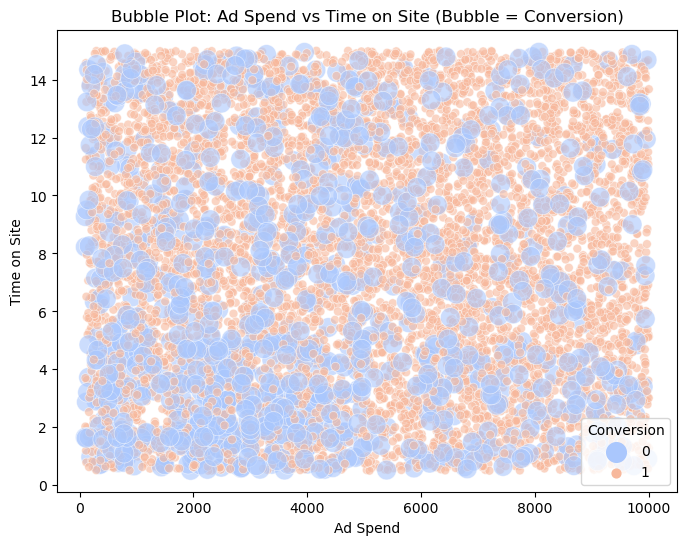

In [14]:
#bubble plot: ad spend vs time on site with conversion as size
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=predict_conversion_dataset,
    x="AdSpend",
    y="TimeOnSite",
    size="Conversion",
    sizes=(40, 200),
    hue="Conversion",
    palette="coolwarm",
    alpha=0.6
)
plt.title("Bubble Plot: Ad Spend vs Time on Site (Bubble = Conversion)")
plt.xlabel("Ad Spend")
plt.ylabel("Time on Site")
plt.legend(title="Conversion")
plt.show()


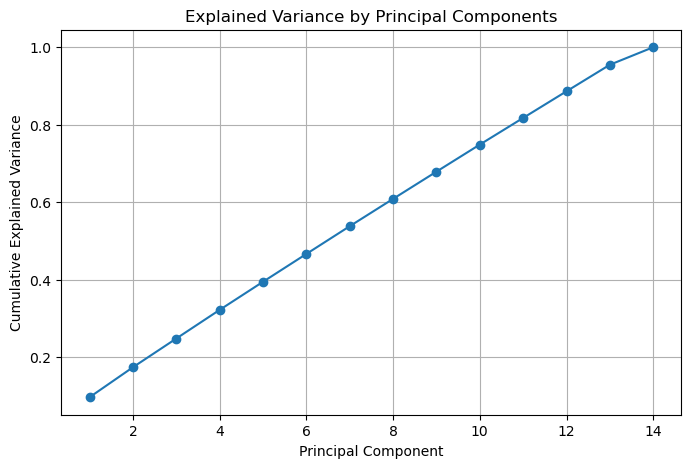

Variance captured by PC1: 9.63%


In [15]:
#drop non-numeric columns if any (e.g., CustomerID)
predict_numeric = predict_conversion_dataset.drop(columns=["CustomerID"])
predict_numeric = predict_numeric.select_dtypes(include=["number"])

#standardize
predict_scaled = StandardScaler().fit_transform(predict_numeric)

#run PCA
pca = PCA()
pca.fit(predict_scaled)

#explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

#plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o')
plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

#print first PC variance
print(f"Variance captured by PC1: {explained_variance[0]:.2%}")


In [16]:
#features and target
features = predict_conversion_dataset[["AdSpend", "EmailClicks", "LoyaltyPoints"]]
target = predict_conversion_dataset["Conversion"]

#fit model
model = LinearRegression()
model.fit(features, target)
preds = model.predict(features)

#evaluate
r2 = r2_score(target, preds)
print(f"Linear Regression R² score (Conversion prediction): {r2:.3f}")


Linear Regression R² score (Conversion prediction): 0.041


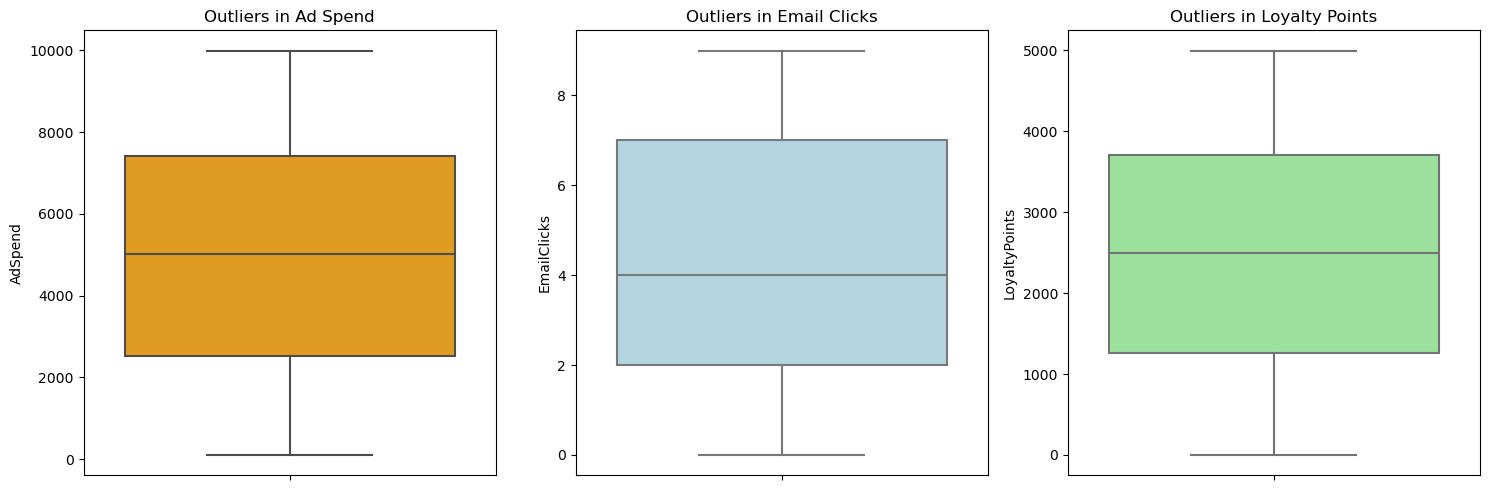

In [17]:
#boxplots
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=predict_conversion_dataset, y="AdSpend", color="orange")
plt.title("Outliers in Ad Spend")

plt.subplot(1, 3, 2)
sns.boxplot(data=predict_conversion_dataset, y="EmailClicks", color="lightblue")
plt.title("Outliers in Email Clicks")

plt.subplot(1, 3, 3)
sns.boxplot(data=predict_conversion_dataset, y="LoyaltyPoints", color="lightgreen")
plt.title("Outliers in Loyalty Points")

plt.tight_layout()
plt.show()


### Predict Conversion Dataset Analysis Summary

#### Bubble Plot
The bubble plot of Ad Spend vs. Time on Site (bubble = Conversion) shows:
- No obvious visual pattern differentiates converted vs. non-converted customers.
- Both classes (converted and non-converted) are distributed widely across all values of ad spend and site time.
- This suggests these features alone are not strong indicators of conversion behavior.

#### Principal Component Analysis (PCA)
- PC1 captures 9.63% of the variance — relatively low.
- Variance is distributed across many components; it takes about 10 components to explain ~80% of total variance.
- This implies high dimensionality and feature redundancy, making PCA-based dimensionality reduction less effective unless many components are retained.

#### Linear Regression (Conversion ~ AdSpend + EmailClicks + LoyaltyPoints)
- R² = 0.041, indicating very weak predictive power.
- Despite being top-correlated, these features don’t explain much of the variation in conversion outcome.

#### Outlier Detection
- Ad Spend varies from near-zero to 10,000 with no extreme outliers — fairly uniform.
- Email Clicks ranges from 0 to 9 — no strong outliers.
- Loyalty Points shows some skewness but no values beyond logical upper bounds.

### Conclusions

- This dataset is noisy and high-dimensional, with weak correlations between individual features and the target (Conversion).
- PCA suggests low feature dominance; no single direction captures strong trends.
- Outliers are minimal, but the overall structure of the data may require:
  - Feature engineering (e.g., interaction terms, binning)
  - Non-linear models (e.g., tree-based classifiers)
  - Dimensionality reduction for visualization, but likely not for prediction



# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

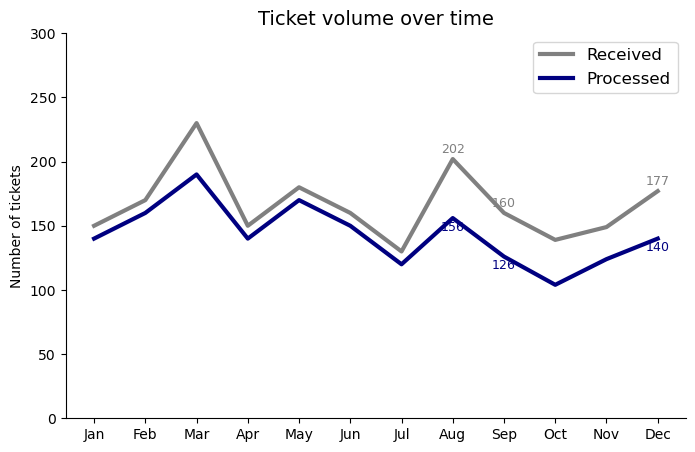

In [3]:
#figure 5.9 from the book
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
received = [150, 170, 230, 150, 180, 160, 130, 202, 160, 139, 149, 177]
processed = [140, 160, 190, 140, 170, 150, 120, 156, 126, 104, 124, 140]


plt.figure(figsize=(8, 5))
plt.plot(months, received, color='gray', linewidth=3, label='Received')
plt.plot(months, processed, color='navy', linewidth=3, label='Processed')

for i, (r, p) in enumerate(zip(received, processed)):
    if i in [7, 8, 11]:  # Annotate Aug, Sep, Dec only
        plt.text(months[i], r + 5, str(r), color='gray', ha='center', fontsize=9)
        plt.text(months[i], p - 10, str(p), color='navy', ha='center', fontsize=9)

plt.title('Ticket volume over time', fontsize=14)
plt.ylabel('Number of tickets')
plt.ylim(0, 300)
plt.legend(loc='upper right', fontsize=12)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.show()
